### Preparação dos dados



In [1]:
# Imports e configuração
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"
TARGET_COL = "Churn"

In [2]:
# Extração do arquivo tratado (JSON)
df = pd.read_json(DATA_URL)
df.shape

(7267, 6)

In [3]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
# Remoção de colunas irrelevantes (ex.: identificadores únicos)
df = df.drop(columns=["customerID"], errors="ignore")
df.head(3)

,Churn,customer,phone,internet,account
0,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [8]:
y = (
    df[TARGET_COL]
    .replace({"Yes":1, "No":0, "Sim":1, "Não":0, "Nao":0, "nao":0, "não":0})
    .replace("", np.nan)
    .fillna(0)
    .astype(int)
)
X = df.drop(columns=[TARGET_COL])

# Coerção ampla para numérico onde fizer sentido (sem perder categóricas)
X_conv = X.copy()
for c in X_conv.columns:
    X_conv[c] = pd.to_numeric(X_conv[c].astype(str).str.replace(",", ".").str.strip(), errors="ignore")

X = X_conv
X.head(3)

C:\Users\victo\AppData\Local\Temp\ipykernel_11452\2334308669.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)
C:\Users\victo\AppData\Local\Temp\ipykernel_11452\2334308669.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_conv[c] = pd.to_numeric(X_conv[c].astype(str).str.replace(",", ".").str.strip(), errors="ignore")
C:\Users\victo\AppData\Local\Temp\ipykernel_11452\2334308669.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_conv[c] = pd.to_numeric(X_conv[c].astype(str).str.replace(",", ".").st

,customer,phone,internet,account
0,{'gender': 'Female'. 'SeniorCitizen': 0. 'Part...,{'PhoneService': 'Yes'. 'MultipleLines': 'No'},{'InternetService': 'DSL'. 'OnlineSecurity': '...,{'Contract': 'One year'. 'PaperlessBilling': '...
1,{'gender': 'Male'. 'SeniorCitizen': 0. 'Partne...,{'PhoneService': 'Yes'. 'MultipleLines': 'Yes'},{'InternetService': 'DSL'. 'OnlineSecurity': '...,{'Contract': 'Month-to-month'. 'PaperlessBilli...
2,{'gender': 'Male'. 'SeniorCitizen': 0. 'Partne...,{'PhoneService': 'Yes'. 'MultipleLines': 'No'},{'InternetService': 'Fiber optic'. 'OnlineSecu...,{'Contract': 'Month-to-month'. 'PaperlessBilli...


Contagem por classe (0=ativo, 1=evadiu):
Churn
0    5398
1    1869
Name: count, dtype: int64

Proporção (%):
Churn
0    74.28
1    25.72
Name: proportion, dtype: float64


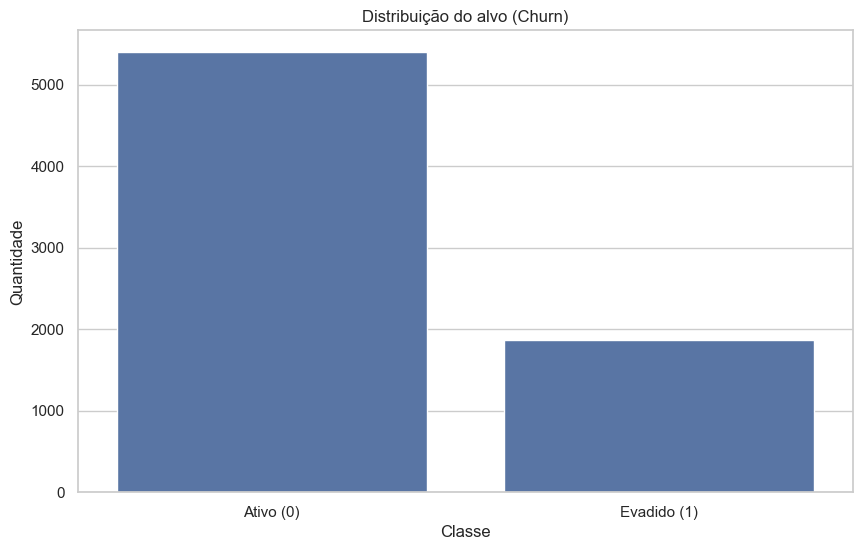

In [9]:
# Verificação da proporção de evasão
print("Contagem por classe (0=ativo, 1=evadiu):")
print(y.value_counts())

print("\nProporção (%):")
print((y.value_counts(normalize=True)*100).round(2))

sns.countplot(x=y.map({0:"Ativo (0)", 1:"Evadido (1)"}))
plt.title("Distribuição do alvo (Churn)")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

In [10]:
# Definição de colunas numéricas e categóricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

In [11]:
# Pré-processamento: com e sem normalização
numeric_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_no_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_scaled = ColumnTransformer([
    ("num", numeric_scaled, numeric_cols),
    ("cat", categorical, categorical_cols)
])

preprocess_no_scale = ColumnTransformer([
    ("num", numeric_no_scale, numeric_cols),
    ("cat", categorical, categorical_cols)
])

### Correlação e análises direcionadas

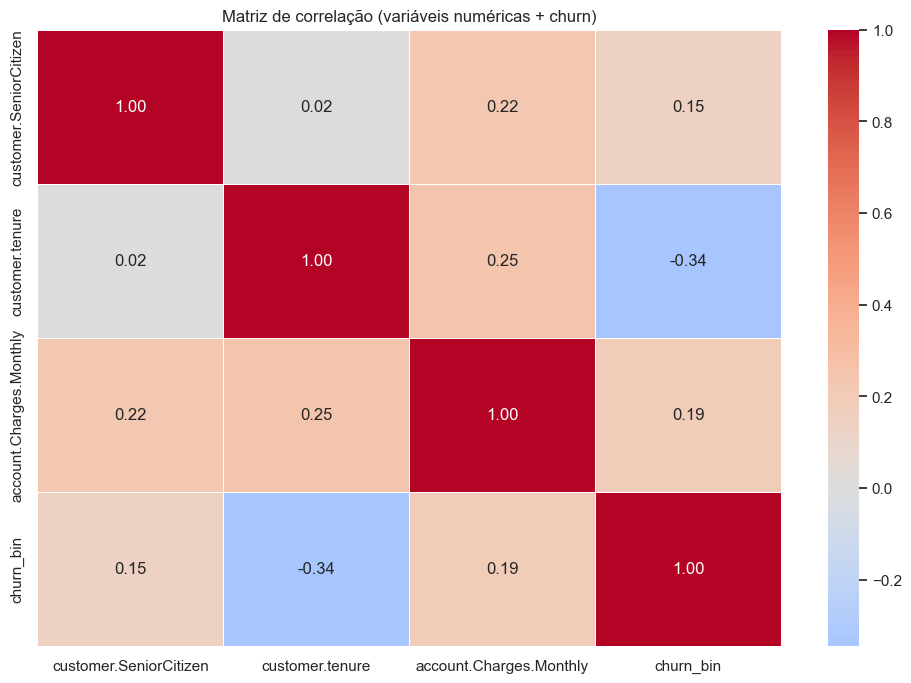

,correlação_com_churn
account.Charges.Monthly,0.189866
customer.SeniorCitizen,0.146733
customer.tenure,-0.344079


In [12]:
# Extrair colunas numéricas dos dicionários aninhados
X_flattened = pd.json_normalize(df.to_dict('records'))

# Selecionar apenas as colunas numéricas do dataframe achatado
X_num = X_flattened.select_dtypes(include=[np.number])

# Concatenar com o alvo
Xy_num = pd.concat([X_num, y.rename("churn_bin")], axis=1)

# Matriz de correlação (variáveis numéricas + alvo)
corr = Xy_num.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=.5)
plt.title("Matriz de correlação (variáveis numéricas + churn)")
plt.show()

churn_corr = corr["churn_bin"].drop("churn_bin").sort_values(ascending=False)
display(churn_corr.to_frame("correlação_com_churn").head(15))

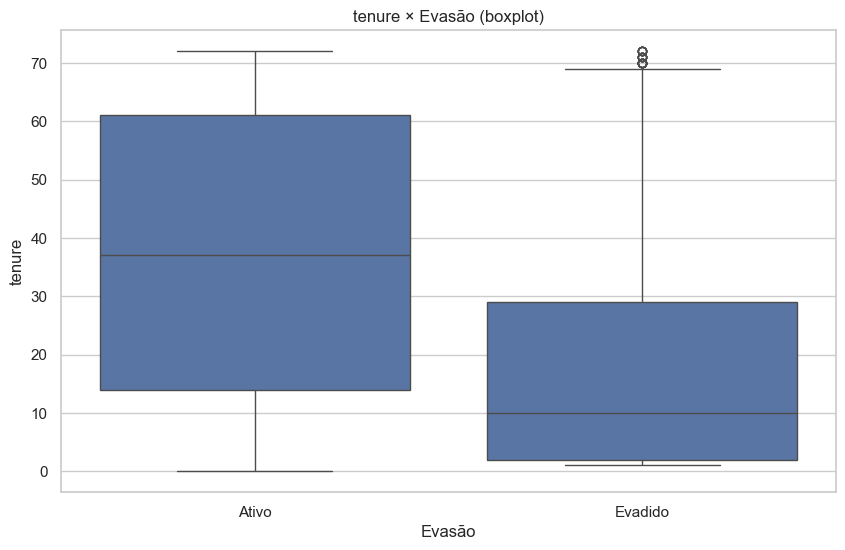

In [13]:
# Análises direcionadas: Tempo de contrato × Evasão; Total gasto × Evasão
# Access 'tenure' and 'TotalCharges' from the flattened DataFrame X_flattened
sns.boxplot(x=y.map({0:"Ativo",1:"Evadido"}), y=X_flattened["customer.tenure"])
plt.title("tenure × Evasão (boxplot)")
plt.xlabel("Evasão")
plt.ylabel("tenure")
plt.show()

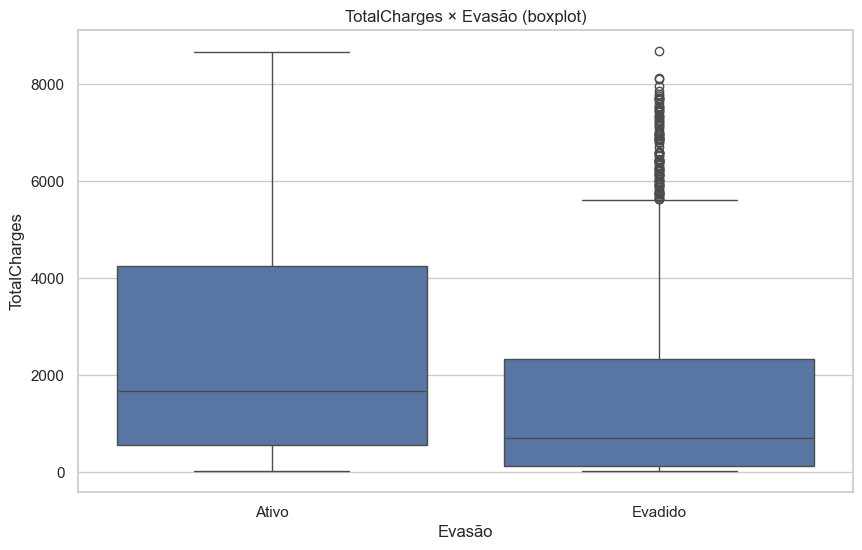

In [14]:
sns.boxplot(x=y.map({0:"Ativo",1:"Evadido"}), y=pd.to_numeric(X_flattened["account.Charges.Total"].astype(str).str.replace(",", ".").str.strip(), errors="coerce"))
plt.title("TotalCharges × Evasão (boxplot)")
plt.xlabel("Evasão")
plt.ylabel("TotalCharges")
plt.show()


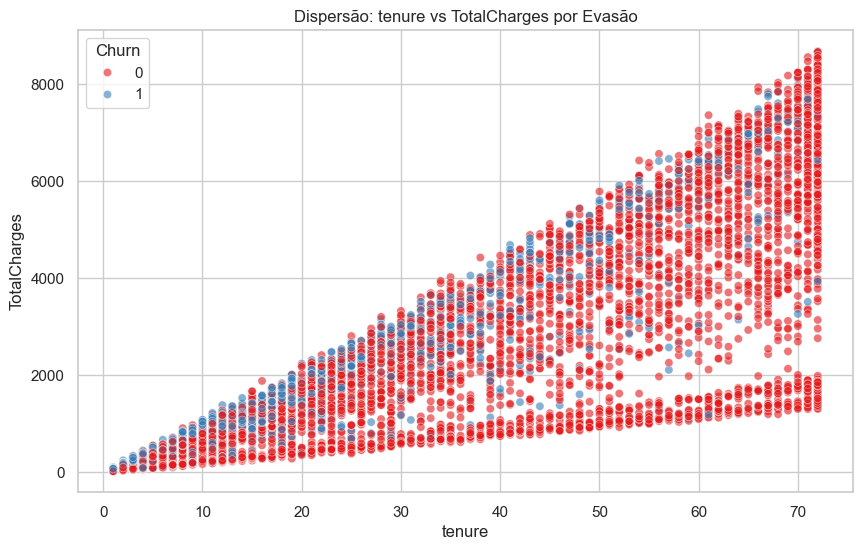

In [15]:
sns.scatterplot(
    x=X_flattened["customer.tenure"],
    y=pd.to_numeric(X_flattened["account.Charges.Total"].astype(str).str.replace(",", ".").str.strip(), errors="coerce"),
    hue=y, palette="Set1", alpha=0.6
)
plt.title("Dispersão: tenure vs TotalCharges por Evasão")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.show()

### Modelagem preditiva

In [16]:
# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((5086, 4), (2181, 4))

In [17]:
# Modelos (um com normalização e outro sem)
pipe_lr = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess_no_scale),
    ("model", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1))
])

# Versões com balanceamento (SMOTE)
pipe_lr_smote = ImbPipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipe_rf_smote = ImbPipeline(steps=[
    ("preprocess", preprocess_no_scale),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1))
])

In [18]:
# Função de avaliação
def evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    metrics = {
        "accuracy_train": accuracy_score(y_train, y_pred_train),
        "precision_train": precision_score(y_train, y_pred_train, zero_division=0),
        "recall_train": recall_score(y_train, y_pred_train, zero_division=0),
        "f1_train": f1_score(y_train, y_pred_train, zero_division=0),
        "accuracy_test": accuracy_score(y_test, y_pred_test),
        "precision_test": precision_score(y_test, y_pred_test, zero_division=0),
        "recall_test": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_test": f1_score(y_test, y_pred_test, zero_division=0),
    }

    print(f"\n=== {name} ===")
    print(pd.Series(metrics).round(4))

    print("\nClassification report (teste):")
    print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))

    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusão — {name}")
    plt.xlabel("Predito")
    plt.ylabel("Verdadeiro")
    plt.show()

    return metrics, model

# Treino e avaliação


=== Logistic Regression (sem SMOTE) ===
accuracy_train     0.9005
precision_train    0.9143
recall_train       0.6766
f1_train           0.7777
accuracy_test      0.7831
precision_test     0.6250
recall_test        0.3922
f1_test            0.4819
dtype: float64

Classification report (teste):
              precision    recall  f1-score   support

           0     0.8136    0.9185    0.8629      1620
           1     0.6250    0.3922    0.4819       561

    accuracy                         0.7831      2181
   macro avg     0.7193    0.6553    0.6724      2181
weighted avg     0.7651    0.7831    0.7649      2181



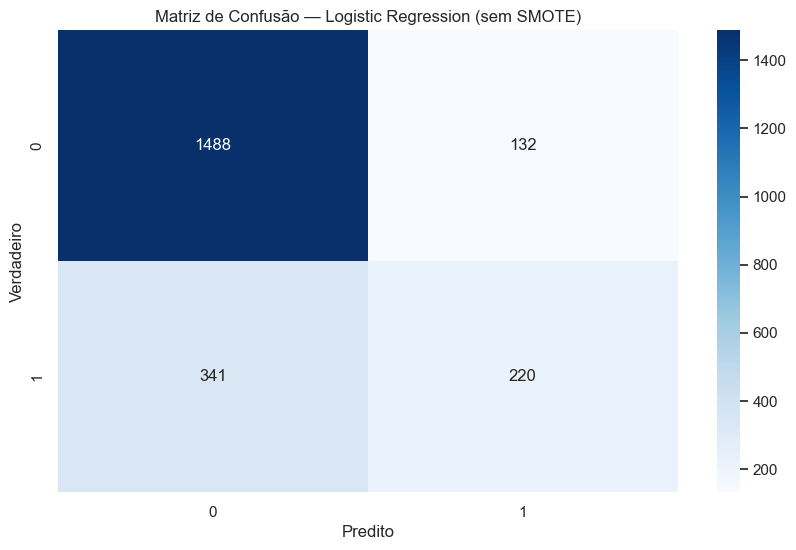

In [19]:
results = {}

m_lr, fitted_lr = evaluate(pipe_lr, X_train, y_train, X_test, y_test, "Logistic Regression (sem SMOTE)")
results["LR_no_smote"] = m_lr


=== Random Forest (sem SMOTE) ===
accuracy_train     0.9921
precision_train    0.9900
recall_train       0.9794
f1_train           0.9846
accuracy_test      0.7648
precision_test     0.5822
recall_test        0.3030
f1_test            0.3986
dtype: float64

Classification report (teste):
              precision    recall  f1-score   support

           0     0.7930    0.9247    0.8538      1620
           1     0.5822    0.3030    0.3986       561

    accuracy                         0.7648      2181
   macro avg     0.6876    0.6139    0.6262      2181
weighted avg     0.7388    0.7648    0.7367      2181



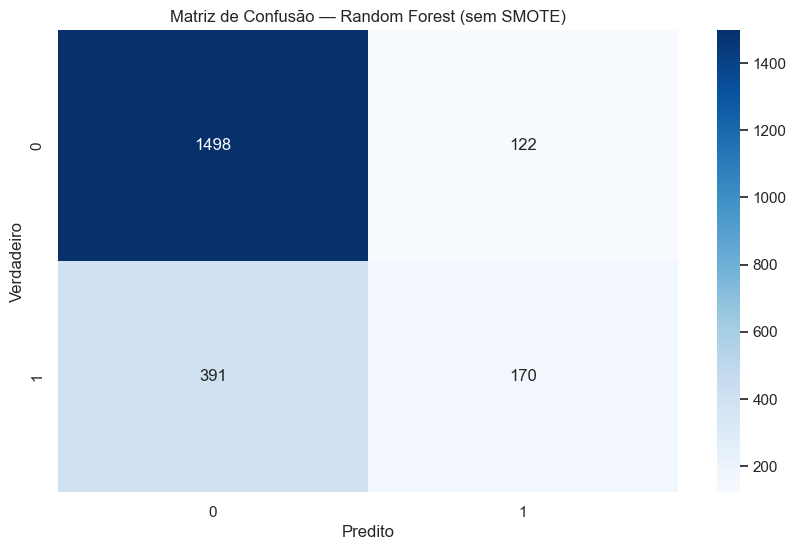

In [20]:
m_rf, fitted_rf = evaluate(pipe_rf, X_train, y_train, X_test, y_test, "Random Forest (sem SMOTE)")
results["RF_no_smote"] = m_rf


=== Logistic Regression (com SMOTE) ===
accuracy_train     0.9127
precision_train    0.7895
recall_train       0.9006
f1_train           0.8414
accuracy_test      0.7671
precision_test     0.5420
recall_test        0.6096
f1_test            0.5738
dtype: float64

Classification report (teste):
              precision    recall  f1-score   support

           0     0.8587    0.8216    0.8397      1620
           1     0.5420    0.6096    0.5738       561

    accuracy                         0.7671      2181
   macro avg     0.7004    0.7156    0.7068      2181
weighted avg     0.7772    0.7671    0.7713      2181



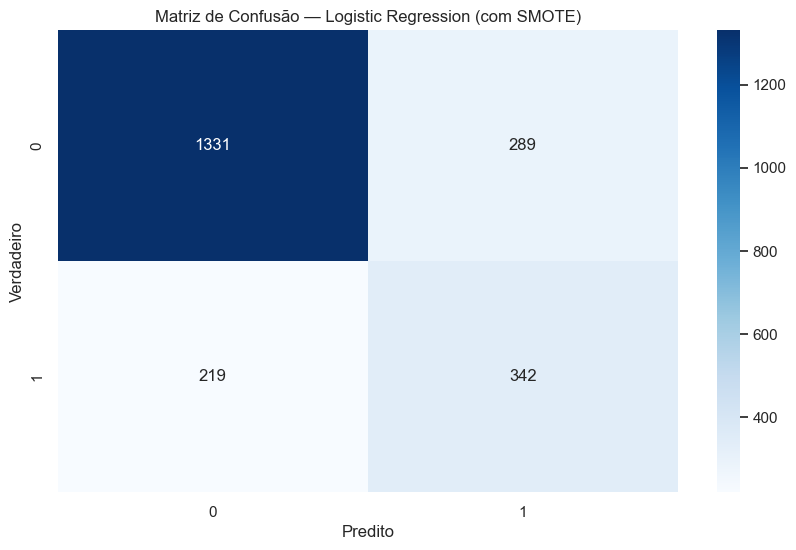

In [22]:
m_lr_s, fitted_lr_s = evaluate(pipe_lr_smote, X_train, y_train, X_test, y_test, "Logistic Regression (com SMOTE)")
results["LR_smote"] = m_lr_s


=== Random Forest (com SMOTE) ===
accuracy_train     0.9921
precision_train    0.9825
recall_train       0.9870
f1_train           0.9847
accuracy_test      0.7643
precision_test     0.5644
recall_test        0.3672
f1_test            0.4449
dtype: float64

Classification report (teste):
              precision    recall  f1-score   support

           0     0.8045    0.9019    0.8504      1620
           1     0.5644    0.3672    0.4449       561

    accuracy                         0.7643      2181
   macro avg     0.6844    0.6345    0.6477      2181
weighted avg     0.7427    0.7643    0.7461      2181



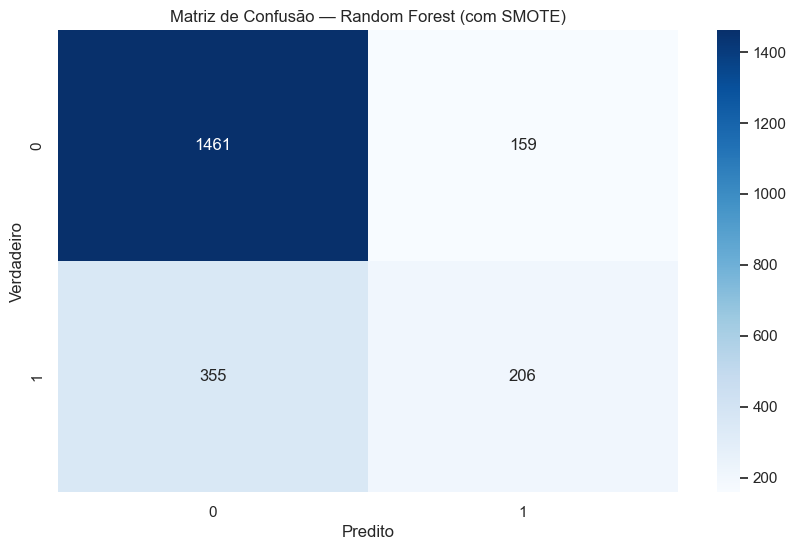

In [23]:
m_rf_s, fitted_rf_s = evaluate(pipe_rf_smote, X_train, y_train, X_test, y_test, "Random Forest (com SMOTE)")
results["RF_smote"] = m_rf_s

In [24]:
pd.DataFrame(results).T.sort_values("f1_test", ascending=False)

,accuracy_train,precision_train,recall_train,f1_train,accuracy_test,precision_test,recall_test,f1_test
LR_smote,0.912702,0.789544,0.900612,0.841429,0.767079,0.541997,0.609626,0.573826
LR_no_smote,0.900511,0.914256,0.676606,0.777680,0.783127,0.625000,0.392157,0.481928
RF_smote,0.992135,0.982496,0.987003,0.984744,0.764328,0.564384,0.367201,0.444924
RF_no_smote,0.992135,0.989954,0.979358,0.984627,0.764787,0.582192,0.303030,0.398593


# Interpretação e conclusões

In [25]:
# Nomes de features após o pré-processamento
def get_feature_names(preprocessor: ColumnTransformer):
    names = []
    names.extend(preprocessor.transformers_[0][2])  # numéricas originais
    cat_pipe = preprocessor.transformers_[1][1]
    ohe = cat_pipe.named_steps["onehot"]
    cats_in = preprocessor.transformers_[1][2]
    names.extend(ohe.get_feature_names_out(cats_in).tolist())
    return names

In [26]:
# Resumo textual do desempenho
res_df = pd.DataFrame(results).T.sort_values("f1_test", ascending=False)
best_row = res_df.iloc[0]

print(
    f"- Melhor modelo: {best_row.name} | "
    f"F1 teste: {best_row['f1_test']:.3f} | "
    f"Recall teste: {best_row['recall_test']:.3f} | "
    f"Acurácia teste: {best_row['accuracy_test']:.3f}"
)

gap = best_row["f1_train"] - best_row["f1_test"]
print(f"- Gap F1 (treino - teste): {gap:.3f}")

- Melhor modelo: LR_smote | F1 teste: 0.574 | Recall teste: 0.610 | Acurácia teste: 0.767
- Gap F1 (treino - teste): 0.268


# Conclusões e estratégias de retenção
- Principais fatores: confirme pelos gráficos/coeficientes; em churn de telecom, tenure, tipo de contrato, mensalidade e total gasto costumam emergir como relevantes.
- Possíveis alavancas para reduzir evasão:
- Incentivar contratos mais longos com benefícios claros.
- Ofertas personalizadas para alto risco (descontos, upgrades).
- Onboarding proativo nos primeiros meses para reduzir churn inicial.
- Monitoramento contínuo com alertas e filas de atendimento prioritárias
